<a href="https://colab.research.google.com/github/sahebkumar-ai/celebal_internship/blob/main/Week_6_Saheb_kumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Aim :To build a deep learning model using an autoencoder on the MNIST dataset for removing noise from images and reconstructing clean images.



##Step 1 — Import Libraries & Load Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###Step 2 — Normalize and Reshape Data

In [2]:

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print("Training shape:", x_train.shape)


Training shape: (60000, 28, 28, 1)


###Step 3 — Add Noise to Images

In [3]:
noise_factor = 0.3
x_train_noisy = x_train + noise_factor * np.random.normal(0.0, 1.0, x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0.0, 1.0, x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

##Step 4 — Build Autoencoder Model

In [4]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)

###Step 5 — Compile Model

In [5]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

##Step 6 — Train Model

In [6]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.1588 - val_loss: 0.0978
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0940 - val_loss: 0.0904
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0890 - val_loss: 0.0870
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0867 - val_loss: 0.0850
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0853 - val_loss: 0.0839
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0843 - val_loss: 0.0833
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0835 - val_loss: 0.0824
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0829 - val_loss: 0.0821
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0825 - val_loss: 0.0814
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0820 - val_loss: 0.0811


###Step 7 — Predict Denoised Images

In [7]:
decoded_imgs = autoencoder.predict(x_test_noisy)

print("Min pixel:", decoded_imgs.min())
print("Max pixel:", decoded_imgs.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Min pixel: 1.744858e-11
Max pixel: 0.99909246


##Step 8 — Visualization of Results

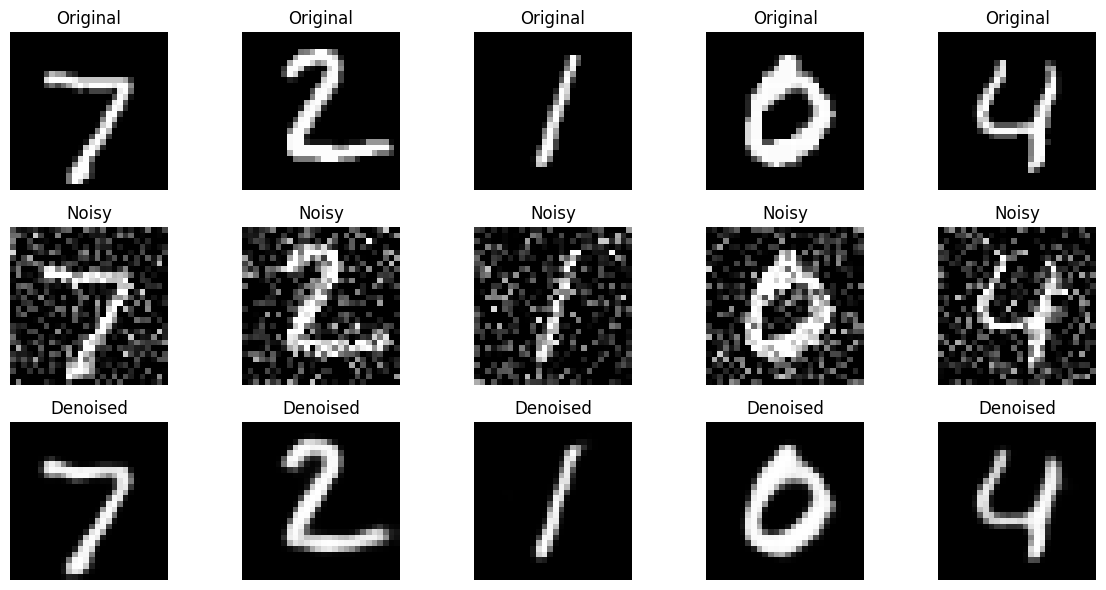

In [8]:
n = 5
plt.figure(figsize=(12, 6))

for i in range(n):

    # Original
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

###Step 9 — Training Performance Graph

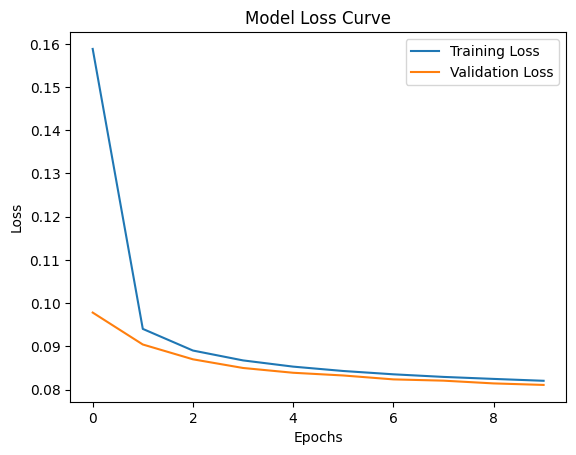

In [9]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

###Step 10 — Conclusion


##Aim
To design and implement a deep learning-based convolutional autoencoder using the MNIST dataset for the purpose of removing noise from images and reconstructing clean handwritten digits.

In this experiment, a convolutional autoencoder was successfully developed and trained using the MNIST dataset for the task of image denoising. The model followed an encoder–decoder architecture, where the encoder learned a compact and meaningful representation of handwritten digit images, and the decoder reconstructed high-quality images from this compressed latent space.

To simulate real-world imperfections, Gaussian noise was deliberately added to the dataset. This allowed the model to learn robust feature extraction and improve its ability to handle distorted inputs. After training, the autoencoder demonstrated strong capability in reconstructing clean images from noisy versions, while preserving important structural and spatial features of the digits.

The consistent reduction in both training loss and validation loss indicated that the model learned effective patterns without overfitting. Furthermore, the visual comparison between original, noisy, and reconstructed images clearly confirmed the effectiveness of the model in performing image restoration.

Overall, this experiment highlights the strength of deep learning-based autoencoders in solving image preprocessing problems such as noise removal, feature learning, and data reconstruction, forming a strong foundation for advanced applications in computer vision and generative models.

## Technologies Used

The experiment was implemented using a modern deep learning and scientific computing stack.

The primary programming language used was Python, chosen for its simplicity and powerful ecosystem for machine learning, numerical analysis, and data visualization. The deep learning model was built using TensorFlow, along with its high-level API Keras, which enabled efficient construction of the convolutional autoencoder architecture, layer definition, and end-to-end training pipeline.

For numerical computation and image processing, NumPy played a crucial role. It was used for data normalization, array reshaping, and synthetic Gaussian noise generation, ensuring proper preparation of the MNIST dataset for training.

The dataset used in this experiment was the MNIST dataset, a widely recognized benchmark in computer vision containing grayscale images of handwritten digits, directly accessible via the Keras datasets module.

For visualization and analysis, Matplotlib was used to generate training/validation loss graphs and to visually compare original, noisy, and reconstructed images, providing clear insight into model performance.

Additionally, the model was trained in a GPU-accelerated environment powered by NVIDIA CUDA and cuDNN, which significantly improved computational efficiency and reduced training time for convolutional operations.

## Final Insight

The integration of Python, TensorFlow/Keras, NumPy, Matplotlib, and GPU acceleration created a powerful and efficient deep learning pipeline. This experiment demonstrates how convolutional autoencoders can effectively learn image representations and perform noise removal, making them highly valuable for real-world applications in image restoration, medical imaging, and computer vision systems.